# Classification Metrics for Rare Incident Prediction

This notebook is executable from the chapter directory.

## Learning goals

Train one incident classifier and evaluate it using confusion-matrix metrics, ROC-AUC, and average precision. Observe why the rare positive class makes accuracy insufficient.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

REPO = Path.cwd().parents[1]
sys.path.insert(0, str(REPO / "src"))

from ml_foundations.data import FEATURE_COLUMNS, temporal_split
from ml_foundations.metrics import binary_metrics

ASSETS = Path.cwd() / "assets"
ASSETS.mkdir(exist_ok=True)
data = pd.read_csv(REPO / "data/incident_priority_synthetic.csv", parse_dates=["timestamp"])
train, validation, test = temporal_split(data)

In [2]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=3000, C=0.5),
)
model.fit(train[FEATURE_COLUMNS], train["is_p1"])
probability = model.predict_proba(test[FEATURE_COLUMNS])[:, 1]

threshold = 0.35
prediction = (probability >= threshold).astype(int)
summary = binary_metrics(test["is_p1"].to_numpy(), prediction)

print("Test positive prevalence:", round(test["is_p1"].mean(), 5))
print("Threshold:", threshold)
for key, value in summary.items():
    print(f"{key:>12}: {value:.5f}")
print("ROC-AUC:", round(roc_auc_score(test["is_p1"], probability), 5))
print("Average precision:", round(average_precision_score(test["is_p1"], probability), 5))

Test positive prevalence: 0.025
Threshold: 0.35
    accuracy: 0.53333
   precision: 0.03913
      recall: 0.75000
 specificity: 0.52778
          f1: 0.07438
          tn: 247.00000
          fp: 221.00000
          fn: 3.00000
          tp: 9.00000
ROC-AUC: 0.74608
Average precision: 0.13623


## Confusion matrix

Read the matrix as operational outcomes rather than abstract counts.

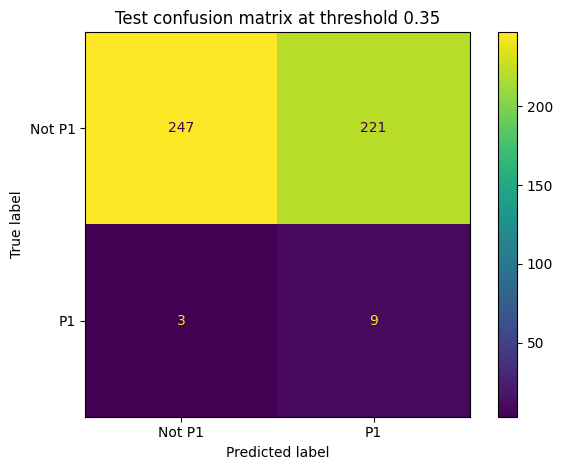

In [3]:
cm = confusion_matrix(test["is_p1"], prediction)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not P1", "P1"])
disp.plot(values_format="d")
plt.title(f"Test confusion matrix at threshold {threshold}")
plt.tight_layout()
plt.savefig(ASSETS / "confusion_matrix.png", dpi=160)
plt.show()

## ROC curve

ROC plots recall against false-positive rate across thresholds.

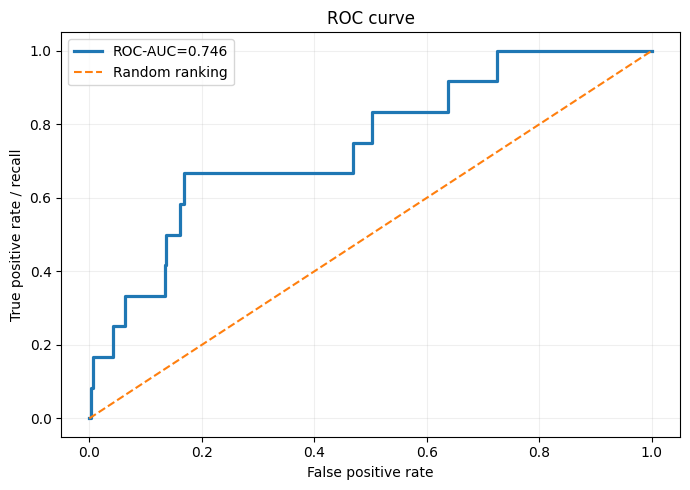

In [4]:
fpr, tpr, roc_thresholds = roc_curve(test["is_p1"], probability)
roc_auc = roc_auc_score(test["is_p1"], probability)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2.3, label=f"ROC-AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random ranking")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate / recall")
plt.title("ROC curve")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "roc_curve.png", dpi=160)
plt.show()

## Precision-recall curve

The horizontal reference is positive prevalence. Average precision summarizes positive-class retrieval across thresholds.

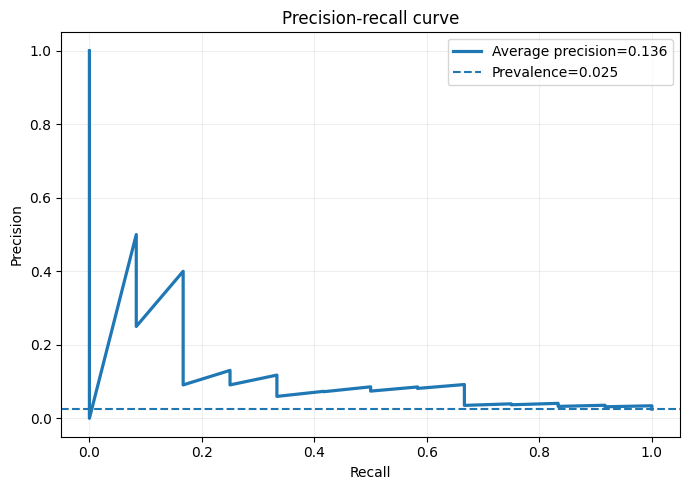

In [5]:
precision, recall, pr_thresholds = precision_recall_curve(test["is_p1"], probability)
ap = average_precision_score(test["is_p1"], probability)
prevalence = test["is_p1"].mean()

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2.3, label=f"Average precision={ap:.3f}")
plt.axhline(prevalence, linestyle="--", label=f"Prevalence={prevalence:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curve")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "pr_curve.png", dpi=160)
plt.show()

## Threshold scorecard

AUC does not choose a deployment threshold. Compare workload and errors at candidate thresholds.

In [6]:
rows = []
for t in [0.15, 0.25, 0.35, 0.45, 0.55, 0.70]:
    pred = (probability >= t).astype(int)
    row = binary_metrics(test["is_p1"].to_numpy(), pred)
    row["threshold"] = t
    row["alerts"] = int(pred.sum())
    rows.append(row)

scorecard = pd.DataFrame(rows)[
    ["threshold", "alerts", "precision", "recall", "specificity", "f1", "fp", "fn"]
]
scorecard

,threshold,alerts,precision,recall,specificity,f1,fp,fn
0,0.15,347,0.031700,0.916667,0.282051,0.061281,336.0,1.0
1,0.25,281,0.035587,0.833333,0.420940,0.068259,271.0,2.0
2,0.35,230,0.039130,0.750000,0.527778,0.074380,221.0,3.0
3,0.45,184,0.043478,0.666667,0.623932,0.081633,176.0,4.0
4,0.55,142,0.056338,0.666667,0.713675,0.103896,134.0,4.0
5,0.70,93,0.086022,0.666667,0.818376,0.152381,85.0,4.0


## Interview reflection

Explain why the same model can have a strong ROC-AUC, a modest average precision, and unacceptable alert volume at one threshold without any contradiction.